# NYC Job Salary Range Prediction

**Machine Learning Internship Project**

### Objective
Predict the **minimum and maximum annual salary** of a NYC government job posting using structured job information and text-based features.

This notebook keeps the original project approach—EDA, salary annualization, Sentence Transformer embeddings, CatBoost encoding, and LightGBM regression—but cleans up the workflow and prevents target leakage during categorical encoding.

> **Google Colab note:** The notebook is designed to run in Google Colab. Update `DATA_PATH` if your dataset is stored in a different Google Drive folder.


## 1. Install Required Libraries

The project uses a small set of additional libraries for categorical encoding, sentence embeddings, LightGBM, and word clouds.


In [1]:
# Run this cell once in Google Colab
!pip -q install category_encoders sentence-transformers lightgbm wordcloud joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 7.4 MB/s eta 0:00:00


## 2. Import Libraries


In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer
import category_encoders as ce

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from lightgbm import LGBMRegressor

# Keep plots readable in Colab
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 3. Mount Google Drive and Load the Dataset


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Change this path if your CSV is stored elsewhere in Google Drive.
DATA_PATH = '/content/drive/MyDrive/Portfolio Website/Projects/NYC Salary Range /Copy of Jobs_NYC_Postings.csv'

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5120, 30)


,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,02,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),82506.0,94882.0,Annual,42-09 28th Street,"Maternal, Infant, & Repr. Hlth","Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",Experience in quantitative research methods an...,**IMPORTANT NOTES TO ALL CANDIDATES: Please n...,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,01/23/2024,22-MAY-2024,01/23/2024,03/04/2024
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Policy, Research & Analysis Public Safety, Ins...",F,Experienced (non-manager),58682.0,134570.0,Annual,30-30 Thomson Ave L I City Qns,Pub Bldgs/Transportation,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates must have excellent management skil...,Authorization to work in the United States is ...,"For City Employees, please go to Employee Self...",35 Hours,"30-30 Thomson Avenue, LIC, NY 11101",NaN,New York City Residency is not required for th...,10/03/2023,NaN,11/29/2023,03/04/2024
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Engineering, Architecture, & Planning",F,Experienced (non-manager),58682.0,91405.0,Annual,30-30 Thomson Ave L I City Qns,PUB BLDGS/CPD/Library/Brooklyn,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates should have at least six years of e...,NaN,NaN,NaN,NaN,NaN,New York City Residency is not required for th...,02/01/2024,NaN,02/01/2024,03/04/2024
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,12158,02,"Finance, Accounting, & Procurement",F,Experienced (non-manager),50972.0,82730.0,Annual,55 Water St Ny Ny,Bridge Repair/352 Kent St,Reporting directly to the Director of Bridge R...,1. A baccalaureate degree from an accredited c...,Familiar with and knowledge of Procurement sys...,The City of New York is an inclusive equal opp...,Resumes may be submitted electronically using ...,9:00am â 5:00pm,To be determine.,NaN,New York City residency is generally required ...,04/04/2023,NaN,04/04/2023,03/04/2024
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,03,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),92301.0,106146.0,Annual,42-09 28th Street,Dis-Div. Mgmt. & Sys Coord,"Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",At least five yearsâ work experience in the ...,NaN,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,02/06/2024,05-JUN-2024,02/21/2024,03/04/2024


## 4. Initial Data Exploration

The original notebook checked the shape, descriptive statistics, missing values, and number of unique values. These checks are retained because they give a quick understanding of the dataset before preprocessing.


In [5]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include='all').T)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("\nUnique values:")
display(df.nunique().sort_values(ascending=False).to_frame("Unique Values"))


Shape: (5120, 30)

Data types:
Job ID                             int64
Agency                            object
Posting Type                      object
# Of Positions                     int64
Business Title                    object
Civil Service Title               object
Title Classification              object
Title Code No                     object
Level                             object
Job Category                      object
Full-Time/Part-Time indicator     object
Career Level                      object
Salary Range From                float64
Salary Range To                  float64
Salary Frequency                  object
Work Location                     object
Division/Work Unit                object
Job Description                   object
Minimum Qual Requirements         object
Preferred Skills                  object
Additional Information            object
To Apply                          object
Hours/Shift                       object
Work Location 1           

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job ID,5120.0,NaN,NaN,NaN,598721.366211,28274.636161,469953.0,586358.0,607060.0,621404.0,628806.0
Agency,5120,59,DEPT OF ENVIRONMENT PROTECTION,932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Posting Type,5120,2,Internal,2612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
# Of Positions,5120.0,NaN,NaN,NaN,2.070898,5.799227,1.0,1.0,1.0,1.0,150.0
Business Title,5120,1781,Project Manager,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Civil Service Title,5120,365,COMMUNITY COORDINATOR,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title Classification,5120,5,Competitive-1,3334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title Code No,5120,388,56058,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Level,5120,18,00,2107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Category,5120,183,"Engineering, Architecture, & Planning",785,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


,Missing Values
Recruitment Contact,5120
Post Until,3616
Work Location 1,3229
Hours/Shift,3210
Additional Information,1862
Preferred Skills,1219
To Apply,426
Full-Time/Part-Time indicator,117
Minimum Qual Requirements,43
Job ID,0



Unique values:


,Unique Values
Job ID,2626
Job Description,2518
Business Title,1781
Preferred Skills,1639
To Apply,1332
Division/Work Unit,852
Additional Information,780
Salary Range To,748
Salary Range From,559
Posting Date,448


## 5. Remove Duplicate Rows


In [6]:
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print(f"Removed {before - after} duplicate rows.")
print(f"New shape: {df.shape}")


Removed 19 duplicate rows.
New shape: (5101, 30)


## 6. Exploratory Data Analysis

The main EDA from the original project is retained:
- Salary distribution
- Average salary by career level
- Full-time vs part-time salary comparison
- Salary by common work locations
- Word cloud of job descriptions


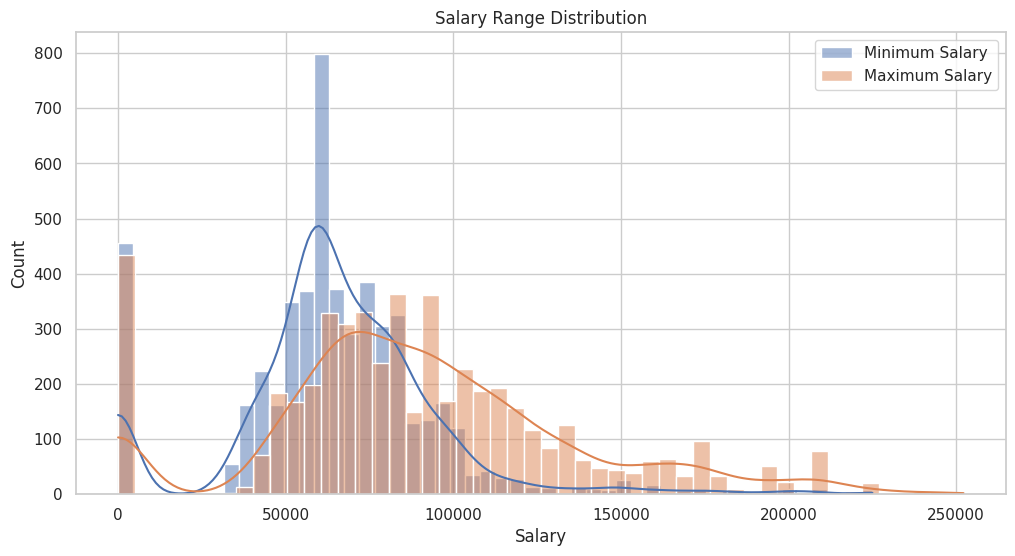

In [7]:
# Salary distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['Salary Range From'], kde=True, bins=50, label='Minimum Salary')
sns.histplot(df['Salary Range To'], kde=True, bins=50, label='Maximum Salary')
plt.title('Salary Range Distribution')
plt.xlabel('Salary')
plt.legend()
plt.show()


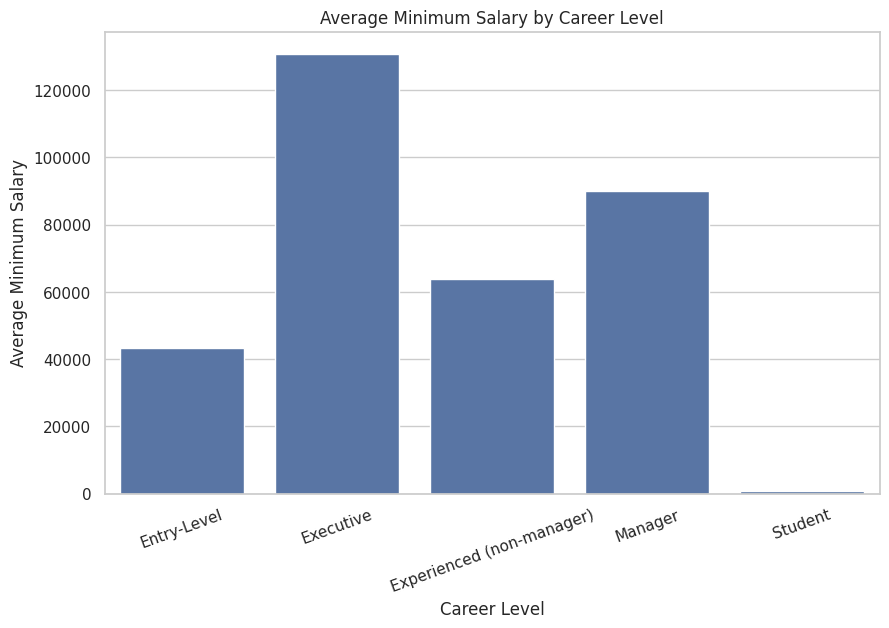

In [8]:
# Average minimum salary by career level
career_salary = (
    df.groupby('Career Level', dropna=False)['Salary Range From']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=career_salary, x='Career Level', y='Salary Range From')
plt.title('Average Minimum Salary by Career Level')
plt.xlabel('Career Level')
plt.ylabel('Average Minimum Salary')
plt.xticks(rotation=20)
plt.show()


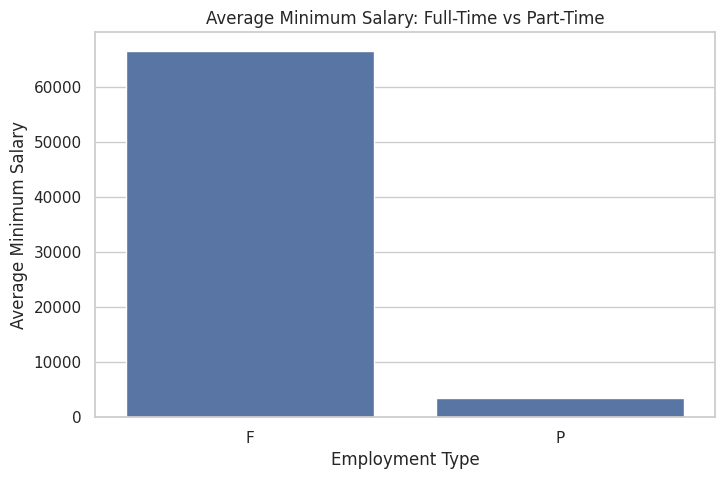

In [9]:
# Full-time vs part-time
ft_salary = (
    df.dropna(subset=['Full-Time/Part-Time indicator'])
      .groupby('Full-Time/Part-Time indicator')['Salary Range From']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=ft_salary, x='Full-Time/Part-Time indicator', y='Salary Range From')
plt.title('Average Minimum Salary: Full-Time vs Part-Time')
plt.xlabel('Employment Type')
plt.ylabel('Average Minimum Salary')
plt.show()


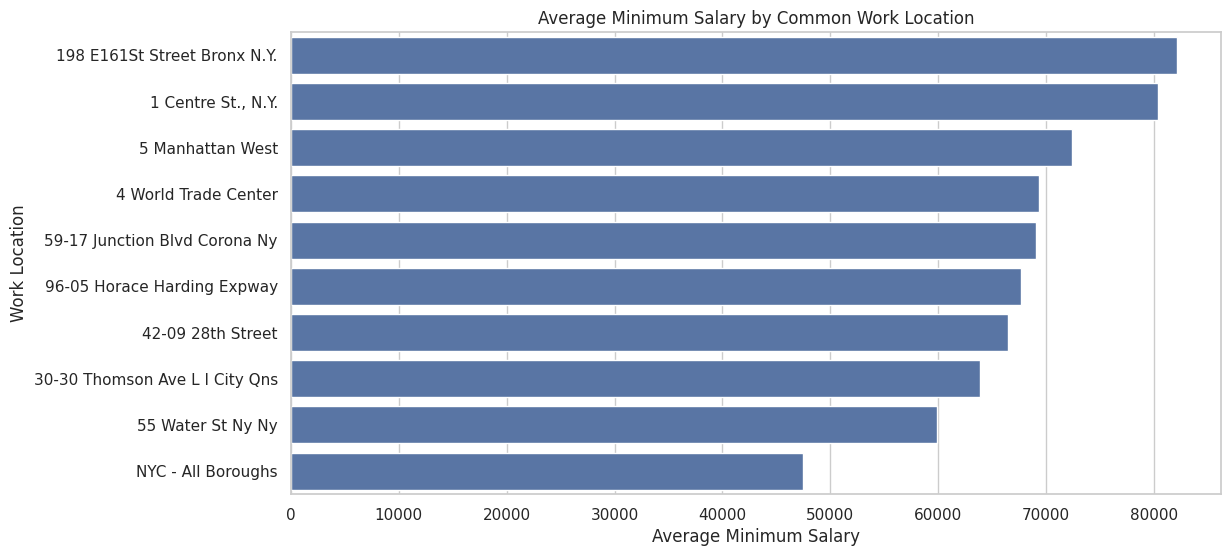

In [10]:
# Average minimum salary for the 10 most common work locations
top_locations = df['Work Location'].value_counts().head(10).index
location_salary = (
    df[df['Work Location'].isin(top_locations)]
      .groupby('Work Location')['Salary Range From']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=location_salary.values, y=location_salary.index)
plt.title('Average Minimum Salary by Common Work Location')
plt.xlabel('Average Minimum Salary')
plt.ylabel('Work Location')
plt.show()


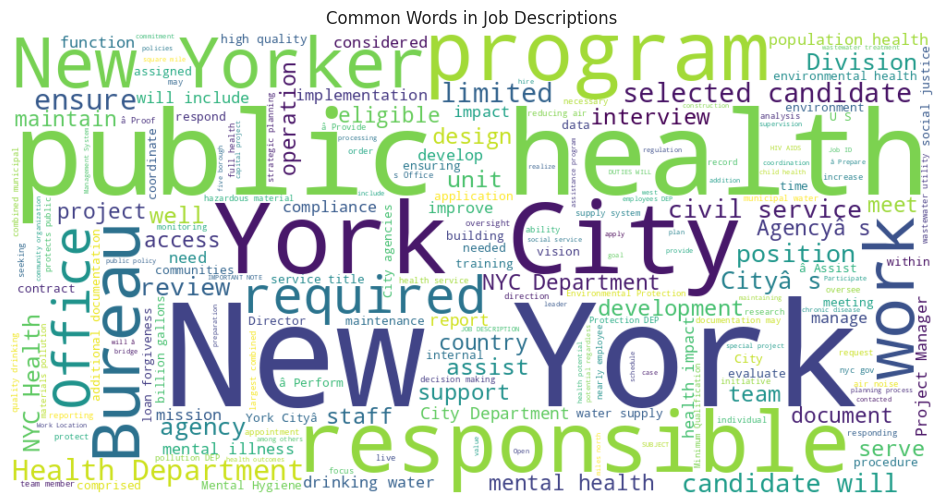

In [11]:
# Word cloud from job descriptions
job_text = ' '.join(df['Job Description'].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(job_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Job Descriptions')
plt.show()


## 7. Data Cleaning

The original project removed identifiers and date fields that were not intended to be used as model features.

Text fields with missing values are filled with `"Not specified"`. Rows missing **Minimum Qual Requirements** are removed, following the original project logic.


In [12]:
columns_to_drop = [
    'Job ID',
    'Recruitment Contact',
    'Posting Date',
    'Post Until',
    'Posting Updated',
    'Process Date',
    'Work Location 1'
]

df = df.drop(columns=columns_to_drop, errors='ignore').copy()

# Fill the employment-type field with its most common value.
df['Full-Time/Part-Time indicator'] = df['Full-Time/Part-Time indicator'].fillna(
    df['Full-Time/Part-Time indicator'].mode()[0]
)

# The original notebook removed rows missing this qualification field.
df = df.dropna(subset=['Minimum Qual Requirements']).copy()

text_columns = [
    'Business Title',
    'Job Description',
    'Minimum Qual Requirements',
    'Preferred Skills',
    'Additional Information',
    'To Apply',
    'Hours/Shift'
]

for col in text_columns:
    df[col] = df[col].fillna('Not specified').astype(str)

print("Shape after cleaning:", df.shape)


Shape after cleaning: (5060, 23)


## 8. Annualize the Salary Targets

Salary values can be reported as annual, monthly, hourly, or daily amounts. To make the prediction task consistent, both salary targets are converted into annual values.

- Annual → × 1
- Monthly → × 12
- Hourly → × 2,080
- Daily → × 260


In [13]:
salary_factors = {
    'Annual': 1,
    'Monthly': 12,
    'Hourly': 2080,  # 40 hours/week × 52 weeks
    'Daily': 260     # 5 days/week × 52 weeks
}

df['Salary Frequency'] = df['Salary Frequency'].fillna('Annual')
df['Salary Frequency'] = df['Salary Frequency'].where(
    df['Salary Frequency'].isin(salary_factors),
    'Annual'
)

df['Annualized_Salary_From'] = (
    df['Salary Range From'] * df['Salary Frequency'].map(salary_factors)
)
df['Annualized_Salary_To'] = (
    df['Salary Range To'] * df['Salary Frequency'].map(salary_factors)
)

# The original salary fields are removed after creating the annualized targets.
df = df.drop(
    columns=['Salary Range From', 'Salary Range To', 'Salary Frequency']
)

print(df[['Annualized_Salary_From', 'Annualized_Salary_To']].describe())


       Annualized_Salary_From  Annualized_Salary_To
count             5060.000000           5060.000000
mean             70207.294424          96034.792562
std              26516.849372          39650.991944
min                  0.000000          21379.800000
25%              55088.000000          67895.250000
50%              64922.000000          88676.000000
75%              81571.000000         115000.000000
max             225000.000000         252165.000000


## 9. Define Features and Targets

The model predicts two values independently:

1. **Annualized Salary From**
2. **Annualized Salary To**

The train/test split is performed **before target encoding**. This is an important improvement over the original notebook because CatBoost encoding uses the target and should not be fitted on the test data.


In [14]:
TARGET_FROM = 'Annualized_Salary_From'
TARGET_TO = 'Annualized_Salary_To'

X = df.drop(columns=[TARGET_FROM, TARGET_TO]).copy()
y_from = df[TARGET_FROM].copy()
y_to = df[TARGET_TO].copy()

X_train, X_test, y_from_train, y_from_test, y_to_train, y_to_test = train_test_split(
    X,
    y_from,
    y_to,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 4048
Testing rows: 1012


## 10. Generate Sentence Transformer Embeddings

The original project used `all-MiniLM-L6-v2` to convert text fields into numerical embeddings.

The same approach is retained. Text embeddings are generated independently of the salary targets, so they can be created before the train/test split without target leakage.


In [15]:
TEXT_COLUMNS = [
    'Business Title',
    'Job Description',
    'Minimum Qual Requirements',
    'Preferred Skills',
    'Additional Information',
    'To Apply',
    'Hours/Shift'
]

TEXT_MODEL_NAME = 'all-MiniLM-L6-v2'
text_model = SentenceTransformer(TEXT_MODEL_NAME)

def add_text_embeddings(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_parts = []
    test_parts = []

    for col in TEXT_COLUMNS:
        train_embeddings = text_model.encode(
            train_df[col].fillna('').astype(str).tolist(),
            show_progress_bar=True
        )
        test_embeddings = text_model.encode(
            test_df[col].fillna('').astype(str).tolist(),
            show_progress_bar=True
        )

        embedding_columns = [
            f'{col}_emb_{i}' for i in range(train_embeddings.shape[1])
        ]

        train_parts.append(pd.DataFrame(
            train_embeddings,
            columns=embedding_columns,
            index=train_df.index
        ))

        test_parts.append(pd.DataFrame(
            test_embeddings,
            columns=embedding_columns,
            index=test_df.index
        ))

    train_text = pd.concat(train_parts, axis=1)
    test_text = pd.concat(test_parts, axis=1)

    train_df = pd.concat([train_df, train_text], axis=1).drop(columns=TEXT_COLUMNS)
    test_df = pd.concat([test_df, test_text], axis=1).drop(columns=TEXT_COLUMNS)

    return train_df, test_df

X_train_encoded, X_test_encoded = add_text_embeddings(X_train, X_test)

print("Training feature shape:", X_train_encoded.shape)
print("Testing feature shape:", X_test_encoded.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/127 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/127 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Training feature shape: (4048, 2701)
Testing feature shape: (1012, 2701)


## 11. Encode Categorical Features

CatBoostEncoder is retained from the original project.

**Improvement:** the encoder is fitted only on `X_train` with `y_from_train`, then used to transform `X_test`. This prevents the target information from the test set from influencing the encoded features.


In [16]:
CATEGORICAL_COLUMNS = [
    'Agency',
    'Posting Type',
    'Civil Service Title',
    'Title Classification',
    'Title Code No',
    'Level',
    'Job Category',
    'Full-Time/Part-Time indicator',
    'Career Level',
    'Work Location',
    'Division/Work Unit',
    'Residency Requirement'
]

cat_encoder = ce.CatBoostEncoder()

X_train_encoded[CATEGORICAL_COLUMNS] = cat_encoder.fit_transform(
    X_train_encoded[CATEGORICAL_COLUMNS],
    y_from_train
)

X_test_encoded[CATEGORICAL_COLUMNS] = cat_encoder.transform(
    X_test_encoded[CATEGORICAL_COLUMNS]
)

print("Categorical encoding completed.")


Categorical encoding completed.


## 12. Build the LightGBM Regression Models

Two LightGBM regressors are used:
- One for minimum annual salary
- One for maximum annual salary

The small preprocessing pipeline standardizes the `# Of Positions` numerical feature and passes the already encoded features through unchanged.


In [17]:
NUMERICAL_COLUMNS = ['# Of Positions']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLUMNS)
    ],
    remainder='passthrough'
)

model_from = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        verbosity=-1
    ))
])

model_to = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        verbosity=-1
    ))
])

model_from.fit(X_train_encoded, y_from_train)
model_to.fit(X_train_encoded, y_to_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['# Of Positions'])])),
                ('regressor',
                 LGBMRegressor(learning_rate=0.05, n_estimators=300,
                               random_state=42, verbosity=-1))])

## 13. Evaluate the Models

RMSE measures the typical prediction error in salary units, while R² shows how much of the variation in the target is explained by the model.


In [18]:
y_from_pred = model_from.predict(X_test_encoded)
y_to_pred = model_to.predict(X_test_encoded)

rmse_from = np.sqrt(mean_squared_error(y_from_test, y_from_pred))
r2_from = r2_score(y_from_test, y_from_pred)

rmse_to = np.sqrt(mean_squared_error(y_to_test, y_to_pred))
r2_to = r2_score(y_to_test, y_to_pred)

results = pd.DataFrame({
    'Target': ['Minimum Annual Salary', 'Maximum Annual Salary'],
    'RMSE': [rmse_from, rmse_to],
    'R²': [r2_from, r2_to]
})

display(results)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Target,RMSE,R²
0,Minimum Annual Salary,7915.713467,0.912586
1,Maximum Annual Salary,7820.765231,0.961652


## 14. Actual vs Predicted Salary

These plots provide a visual check of how closely predictions follow the actual salary values.


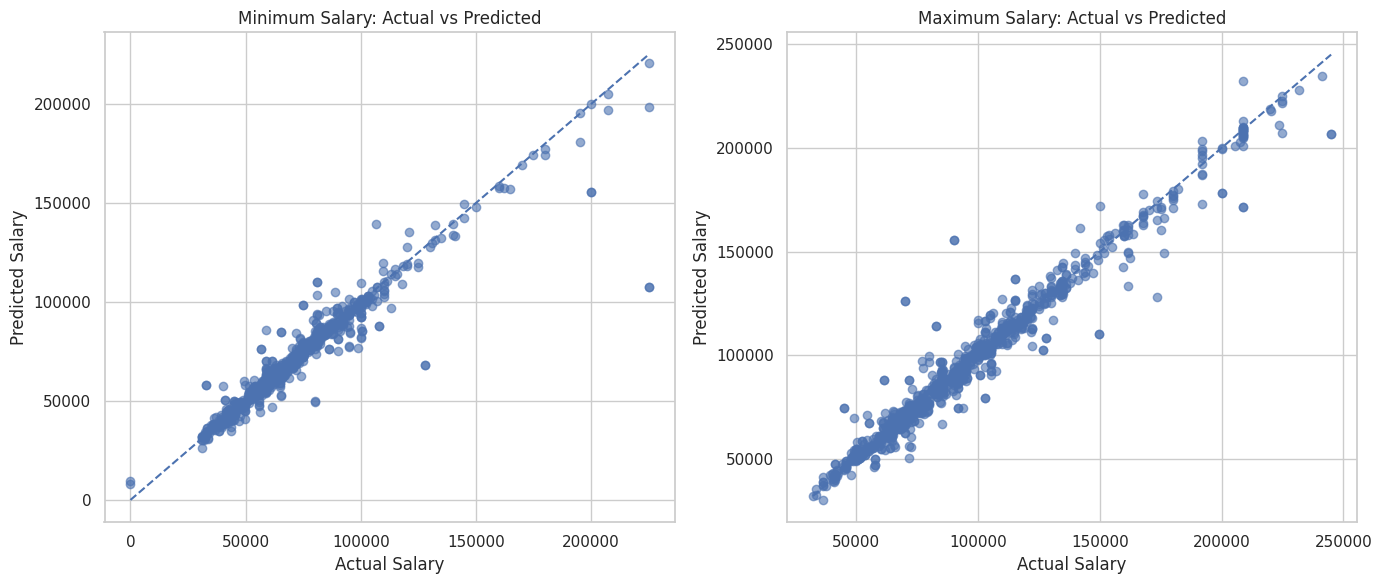

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_from_test, y_from_pred, alpha=0.6)
axes[0].plot(
    [y_from_test.min(), y_from_test.max()],
    [y_from_test.min(), y_from_test.max()],
    linestyle='--'
)
axes[0].set_title('Minimum Salary: Actual vs Predicted')
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')

axes[1].scatter(y_to_test, y_to_pred, alpha=0.6)
axes[1].plot(
    [y_to_test.min(), y_to_test.max()],
    [y_to_test.min(), y_to_test.max()],
    linestyle='--'
)
axes[1].set_title('Maximum Salary: Actual vs Predicted')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')

plt.tight_layout()
plt.show()


## 15. Feature Importance

LightGBM can show which processed features contributed most to each model.

Because the text columns were converted into embeddings, the most important text features are represented by their embedding dimensions rather than human-readable words.


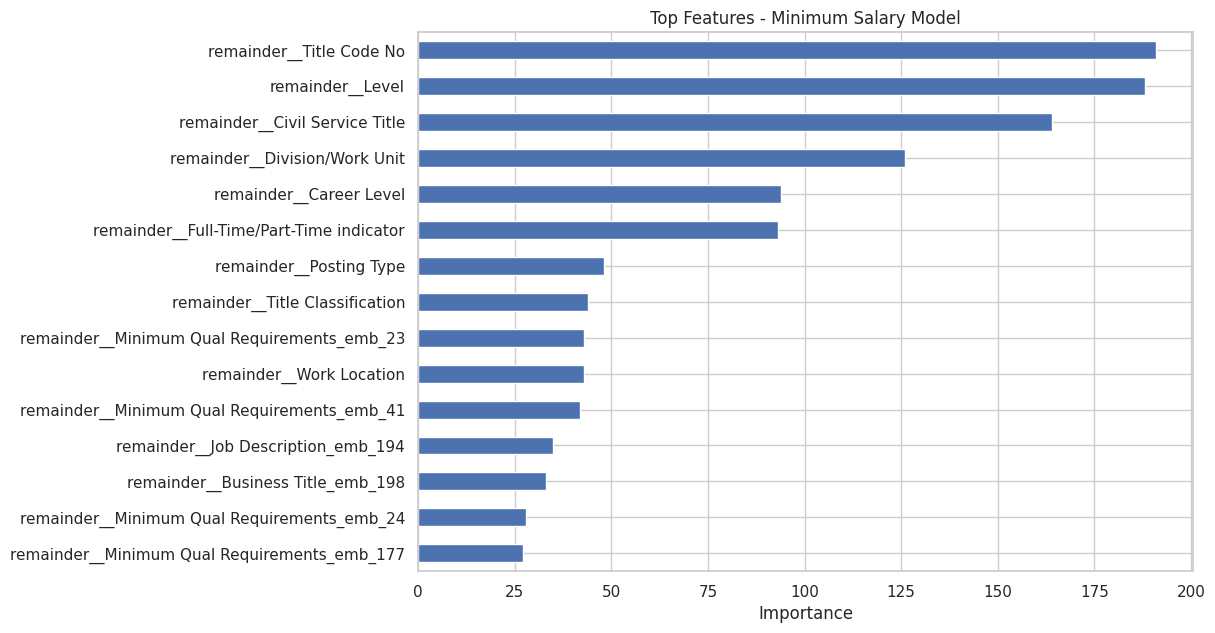

In [20]:
feature_names = model_from.named_steps['preprocessor'].get_feature_names_out()

importance_from = pd.Series(
    model_from.named_steps['regressor'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
importance_from.sort_values().plot(kind='barh')
plt.title('Top Features - Minimum Salary Model')
plt.xlabel('Importance')
plt.show()


## 16. Save Models and Supporting Files

These files are used by the Streamlit application.

The Sentence Transformer model itself is **not** copied into the project. The app downloads/loads the same `all-MiniLM-L6-v2` model by name when it starts.


In [21]:
ARTIFACT_DIR = '/content/drive/MyDrive/Salary_Range_Prediction/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(model_from, f'{ARTIFACT_DIR}/model_from.joblib')
joblib.dump(model_to, f'{ARTIFACT_DIR}/model_to.joblib')
joblib.dump(cat_encoder, f'{ARTIFACT_DIR}/cat_encoder.joblib')

metadata = {
    'text_model_name': TEXT_MODEL_NAME,
    'text_columns': TEXT_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'numerical_columns': NUMERICAL_COLUMNS,
    'target_from': TARGET_FROM,
    'target_to': TARGET_TO,
    'test_size': 0.20,
    'random_state': 42
}

with open(f'{ARTIFACT_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Saved artifacts to:", ARTIFACT_DIR)


Saved artifacts to: /content/drive/MyDrive/Salary_Range_Prediction/artifacts


## 17. Export the Train/Test Split

These files are optional but useful for documenting the project and reproducing the experiment later.


In [22]:
train_export = X_train.copy()
train_export[TARGET_FROM] = y_from_train
train_export[TARGET_TO] = y_to_train

test_export = X_test.copy()
test_export[TARGET_FROM] = y_from_test
test_export[TARGET_TO] = y_to_test

train_export.to_csv(f'{ARTIFACT_DIR}/train.csv', index=False)
test_export.to_csv(f'{ARTIFACT_DIR}/test.csv', index=False)

print("Train/test CSV files saved.")


Train/test CSV files saved.


In [23]:
import sklearn
import joblib
import torch
import sentence_transformers
import lightgbm
import category_encoders
import pandas
import numpy

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("torch:", torch.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("lightgbm:", lightgbm.__version__)
print("category-encoders:", category_encoders.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

scikit-learn: 1.6.1
joblib: 1.5.3
torch: 2.11.0+cpu
sentence-transformers: 5.6.0
lightgbm: 4.6.0
category-encoders: 2.10.0
pandas: 2.2.2
numpy: 2.0.2


## 18. Final Notes

### Main workflow
1. Load NYC job postings.
2. Explore the data.
3. Remove duplicates and irrelevant fields.
4. Handle missing values.
5. Convert salary ranges to annual targets.
6. Split into training and test sets.
7. Generate Sentence Transformer text embeddings.
8. Fit CatBoostEncoder on training data only.
9. Train two LightGBM regression models.
10. Evaluate with RMSE and R².
11. Review actual-vs-predicted performance and feature importance.
12. Save the models and preprocessing artifacts for deployment.

The final model is intended as a **portfolio/student machine learning project**, not as an official salary-setting tool.
